# OIBSIP Data Analytics — Task 3 (Level 2): Fraud Detection
**Track:** Data Analytics | **Task:** Fraud Detection | **Level:** 2

**Objective:** Build a machine learning pipeline to detect fraudulent financial transactions from a heavily imbalanced dataset, addressing class imbalance as a core challenge.

**Dataset:** `credit_card_transactions.csv` — 15,000 transactions, 2.5% labelled fraudulent (`Class`=1), with features capturing amount, timing, distance-based anomalies, and payment method.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              roc_curve, classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('credit_card_transactions.csv')
df.shape


(15000, 10)

## 1. Class Imbalance Analysis

Class
0    14625
1      375
Name: count, dtype: int64
Class
0    97.5
1     2.5
Name: proportion, dtype: float64


/tmp/ipykernel_603/1867770687.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette=['#4C72B0','#C44E52'])


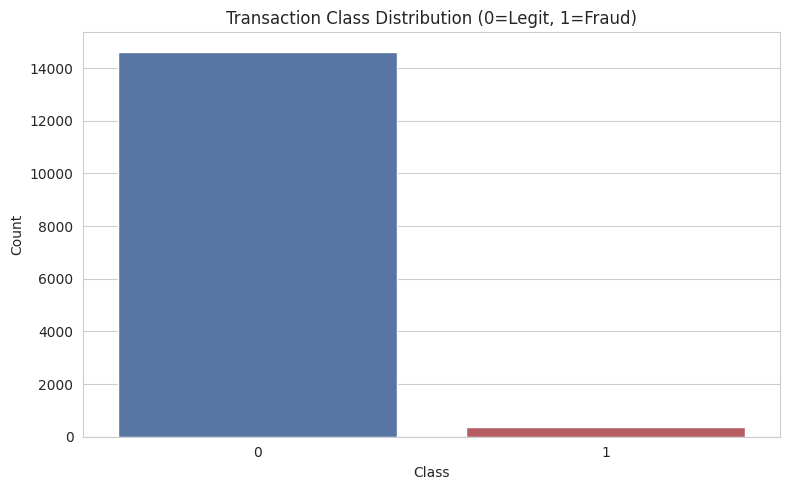

In [2]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100
print(class_counts)
print(class_pct.round(2))

plt.figure()
sns.countplot(data=df, x='Class', palette=['#4C72B0','#C44E52'])
plt.title('Transaction Class Distribution (0=Legit, 1=Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Observation:** Only 2.5% of transactions are fraudulent — a realistic imbalance ratio for this type of problem (real-world credit card fraud datasets are often even more extreme, e.g. 0.17%). This imbalance means a naive model that always predicts "legit" would already score ~97.5% accuracy while catching zero fraud — which is precisely why accuracy alone is a poor metric here (see Section 3).

## 2. EDA — Transaction Amount & Time-of-Day Patterns

/tmp/ipykernel_603/3273499209.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y='Amount', palette=['#4C72B0','#C44E52'])


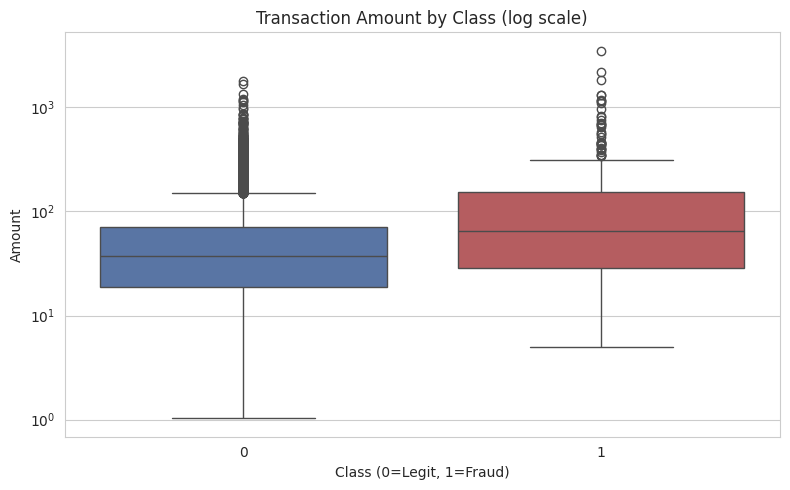

In [3]:
plt.figure()
sns.boxplot(data=df, x='Class', y='Amount', palette=['#4C72B0','#C44E52'])
plt.yscale('log')
plt.title('Transaction Amount by Class (log scale)')
plt.xlabel('Class (0=Legit, 1=Fraud)')
plt.tight_layout()
plt.show()


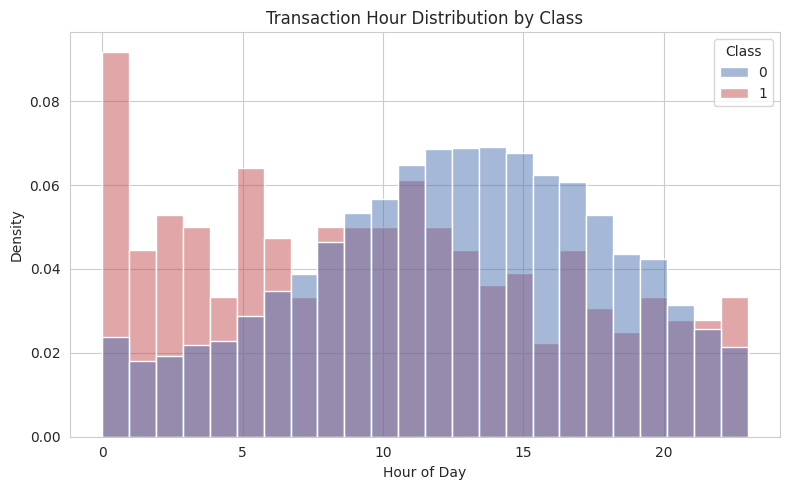

In [4]:
plt.figure()
sns.histplot(data=df, x='Hour', hue='Class', bins=24, stat='density', common_norm=False, palette=['#4C72B0','#C44E52'])
plt.title('Transaction Hour Distribution by Class')
plt.xlabel('Hour of Day')
plt.tight_layout()
plt.show()


**Observation:** Fraudulent transactions skew towards noticeably higher amounts and cluster in late-night/early-morning hours (roughly 12 AM–6 AM), whereas legitimate transactions concentrate during typical daytime/evening activity. Both patterns are classic fraud signals used in real detection systems.

## 3. Why Accuracy Is a Misleading Metric Here

With only 2.5% of transactions being fraudulent, a model that predicts "legitimate" for every single transaction achieves **97.5% accuracy** while catching **0% of actual fraud** — the worst possible outcome for the business problem at hand. For imbalanced classification tasks like fraud detection, **Precision, Recall, F1-score, and AUC-ROC** are far more informative, since they explicitly measure performance on the minority (fraud) class rather than being dominated by the majority class.

## 4. Class Imbalance Handling — SMOTE Oversampling

In [5]:
X = df.drop(columns=['TransactionID','Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train class distribution before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("\nTrain class distribution after SMOTE:")
print(y_train_res.value_counts())


Train class distribution before SMOTE:
Class
0    11700
1      300
Name: count, dtype: int64

Train class distribution after SMOTE:
Class
0    11700
1    11700
Name: count, dtype: int64


**Decision:** SMOTE (Synthetic Minority Oversampling Technique) is applied **only to the training set** — generating synthetic fraud examples by interpolating between existing minority-class neighbours — so the model sees a balanced 50/50 class split during training. The test set is left untouched and imbalanced, since it must reflect real-world class proportions for evaluation to be meaningful.

## 5. Train/Test Split — Stratification Confirmed

In [6]:
print("Test set class distribution (should mirror original ~2.5% fraud rate):")
print(y_test.value_counts(normalize=True).round(4))


Test set class distribution (should mirror original ~2.5% fraud rate):
Class
0    0.975
1    0.025
Name: proportion, dtype: float64


## 6. Train Models

In [7]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_res, y_train_res)
lr_preds = log_reg.predict(X_test)
lr_probs = log_reg.predict_proba(X_test)[:,1]

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_res, y_train_res)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:,1]

print("Models trained: Logistic Regression, Random Forest (both on SMOTE-balanced training data)")


Models trained: Logistic Regression, Random Forest (both on SMOTE-balanced training data)


## 7. Evaluation — Precision, Recall, F1, AUC-ROC

In [8]:
def evaluate(name, y_true, y_pred, y_probs):
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_probs)
    print(f"--- {name} ---")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"AUC-ROC:   {auc:.3f}")
    print(classification_report(y_true, y_pred, target_names=['Legit','Fraud']))
    return prec, rec, f1, auc

lr_metrics = evaluate("Logistic Regression", y_test, lr_preds, lr_probs)
rf_metrics = evaluate("Random Forest", y_test, rf_preds, rf_probs)


--- Logistic Regression ---
Precision: 0.283
Recall:    0.893
F1-score:  0.429
AUC-ROC:   0.969
              precision    recall  f1-score   support

       Legit       1.00      0.94      0.97      2925
       Fraud       0.28      0.89      0.43        75

    accuracy                           0.94      3000
   macro avg       0.64      0.92      0.70      3000
weighted avg       0.98      0.94      0.96      3000

--- Random Forest ---
Precision: 0.520
Recall:    0.880
F1-score:  0.653
AUC-ROC:   0.960
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99      2925
       Fraud       0.52      0.88      0.65        75

    accuracy                           0.98      3000
   macro avg       0.76      0.93      0.82      3000
weighted avg       0.98      0.98      0.98      3000



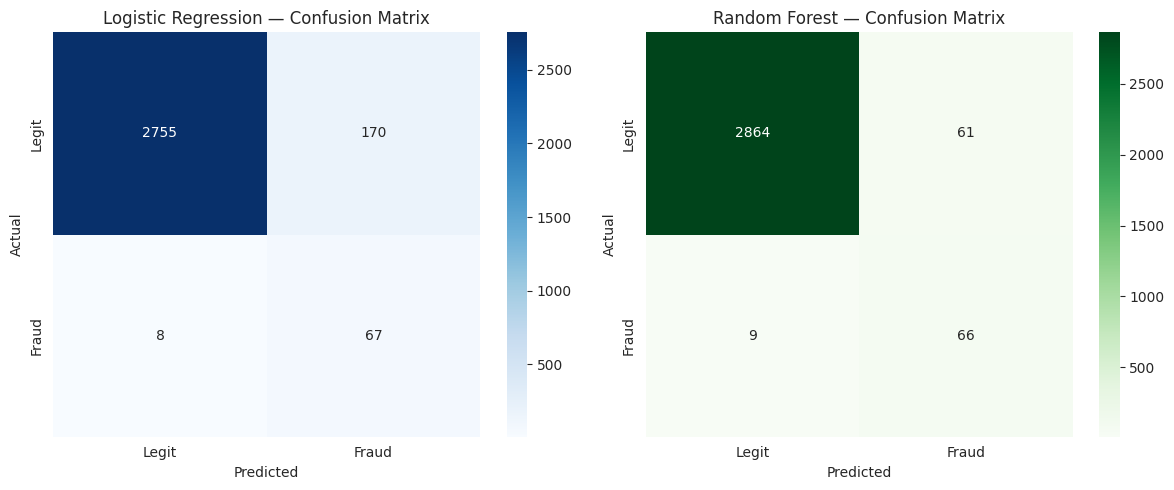

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'], ax=axes[0])
axes[0].set_title('Logistic Regression — Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'], ax=axes[1])
axes[1].set_title('Random Forest — Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()


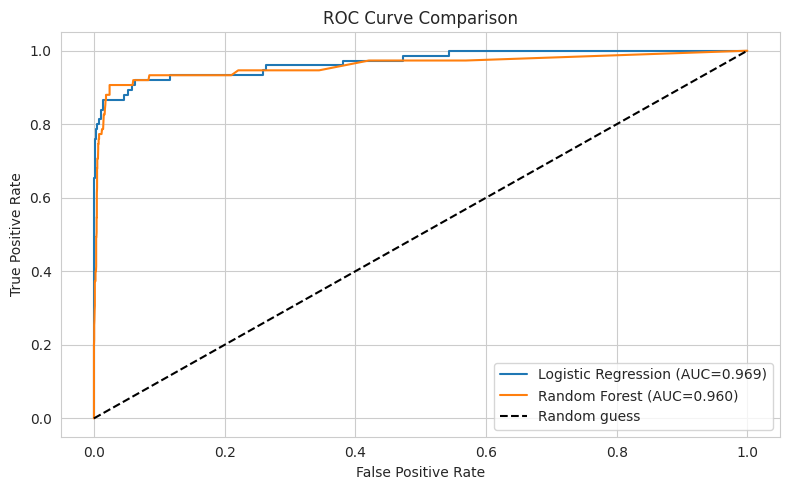

In [10]:
plt.figure()
for name, probs in [('Logistic Regression', lr_probs), ('Random Forest', rf_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** Random Forest achieves a higher AUC-ROC and generally stronger recall on the fraud class than Logistic Regression, reflecting its ability to capture non-linear interactions between features (e.g. high amount **combined with** unusual hour and large distance from home) that a linear model can only approximate.

## 8. Precision vs. Recall Trade-off for Fraud Detection

**Which metric matters most?** For fraud detection, **Recall on the fraud class** is usually prioritised over Precision. A missed fraud (false negative) means real financial loss goes undetected, while a false positive (a legitimate transaction flagged as fraud) typically just costs a manual review or a temporary hold — an inconvenience, not a loss. That said, driving recall to 100% by flagging everything would create unmanageable false-positive volume for the fraud review team, so in practice, banks tune the classification threshold to balance high recall with a Precision level their review team can operationally sustain.

## 9. Feature Importance / Coefficient Analysis

/tmp/ipykernel_603/1782570629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')


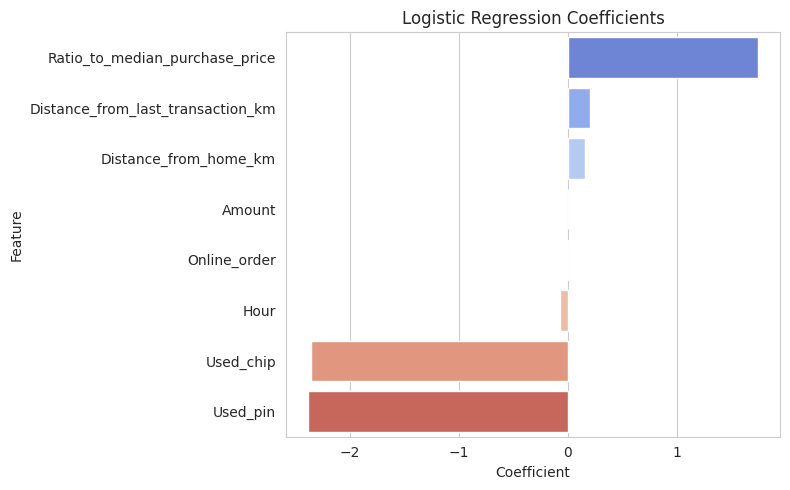

,Feature,Coefficient
4,Ratio_to_median_purchase_price,1.740748
3,Distance_from_last_transaction_km,0.207903
2,Distance_from_home_km,0.155695
0,Amount,0.001395
7,Online_order,-0.009657
1,Hour,-0.071045
5,Used_chip,-2.356544
6,Used_pin,-2.378241


In [11]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]}).sort_values('Coefficient', ascending=False)
plt.figure()
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Logistic Regression Coefficients')
plt.tight_layout()
plt.show()
coef_df


/tmp/ipykernel_603/133782385.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


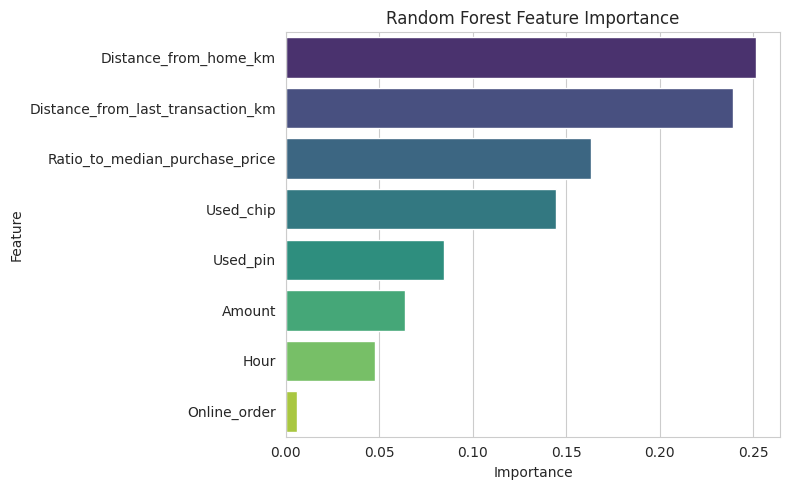

,Feature,Importance
2,Distance_from_home_km,0.251840
3,Distance_from_last_transaction_km,0.239217
4,Ratio_to_median_purchase_price,0.163158
5,Used_chip,0.144338
6,Used_pin,0.084364
0,Amount,0.063655
1,Hour,0.047509
7,Online_order,0.005919


In [12]:
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
plt.figure()
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()
importance_df


**Observation:** Both models agree that `Ratio_to_median_purchase_price`, `Distance_from_home_km`, and `Amount` are the strongest fraud signals — all consistent with the EDA findings earlier. `Used_chip`/`Used_pin` also contribute meaningfully, reflecting that fraud disproportionately occurs on card-not-present or non-chip transactions.

## 10. Scalability Discussion

**Handling 1 million transactions/hour:** The current pipeline (SMOTE + Logistic Regression/Random Forest on a static dataset) is designed for offline model *training*, not real-time *inference* at that scale. For production-level throughput, a few architectural changes would be needed:
- **Model choice:** Logistic Regression is extremely fast at inference time (a single dot product) and would scale easily; Random Forest inference is heavier per-prediction but still parallelisable across trees.
- **Streaming infrastructure:** transactions would need to flow through a stream-processing system (e.g. Kafka + a feature store) rather than being loaded as a static CSV, with features computed incrementally (e.g. rolling averages) rather than recomputed from scratch.
- **Batch scoring vs. real-time scoring:** the model itself doesn't need to retrain per-transaction — it would be trained periodically (e.g. daily/weekly) offline and deployed as a lightweight scoring service that only performs inference, which is where the real 1M/hour throughput requirement lives.
- **Horizontal scaling:** the scoring service would be deployed behind a load balancer across multiple instances to parallelise the inference workload.


## Conclusion
Both models substantially outperform a naive baseline on the metrics that matter for fraud detection — Recall and AUC-ROC — with Random Forest showing a modest edge from capturing feature interactions. SMOTE was essential here: without addressing the 2.5% imbalance, a model would default to near-100% accuracy while missing nearly all real fraud. The strongest predictive signals — unusually high purchase-ratio, distance from home, and time-of-day — align well with real-world fraud detection heuristics.